# Stage 10 — Model Evaluation and Hyperparameter Tuning

The test set is used for final evaluation, not for feature selection or hyperparameter tuning. Model choice is based on training cross-validation.

## 10.1 Training cross-validation model comparison

At this point, the test set is still not used. The table below reports only training cross-validation performance from Stage 9. This keeps model comparison independent from the final test evaluation.

In [384]:
training_cv_summary = cv_results.copy()
training_cv_summary.to_csv(TABLE_DIR / "training_cv_model_comparison_before_tuning.csv", index=False)
display(training_cv_summary)


,model,cv_rmse_log_mean,cv_rmse_log_std
5,Extra Trees,0.438749,0.136656
6,Gradient Boosting,0.464387,0.105211
7,XGBoost,0.478287,0.117580
4,Random Forest,0.495455,0.109599
3,KNN,0.521236,0.070717
1,Ridge,0.555604,0.138292
2,ElasticNet,0.809528,0.186305
0,Dummy mean,1.039777,0.177150


## 10.2 Training cross-validation comparison plot

This plot compares the candidate models using cross-validation on the training set only. It is used to decide which models should enter hyperparameter tuning.

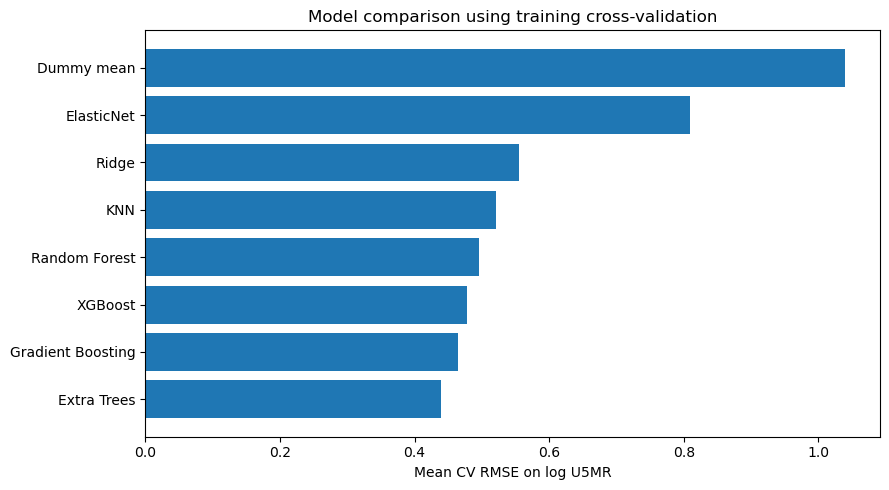

In [386]:
plot_df = cv_results.sort_values("cv_rmse_log_mean", ascending=True).copy()

plt.figure(figsize=(9, 5))
plt.barh(plot_df["model"], plot_df["cv_rmse_log_mean"])
plt.title("Model comparison using training cross-validation")
plt.xlabel("Mean CV RMSE on log U5MR")
plt.tight_layout()
plt.savefig(VIS_DIR / "training_cv_model_comparison_rmse_log.png", dpi=300)
plt.show()


## 10.3 Modest hyperparameter tuning on training data only

The best models from cross-validation are tuned with small search spaces because the dataset contains fewer than 200 countries. Tuning is done only on the training set. XGBoost is included when the package is available.

In [388]:
top_models_for_tuning = cv_results[cv_results["model"] != "Dummy mean"].head(3)["model"].tolist()
print("Models selected for tuning based on training CV:", top_models_for_tuning)

param_grids = {
    "Ridge": {
        "model__alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
    },
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "Random Forest": {
        "model__n_estimators": [300, 600],
        "model__max_depth": [None, 6, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 1.0]
    },
    "Extra Trees": {
        "model__n_estimators": [300, 600],
        "model__max_depth": [None, 6, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 1.0]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3],
        "model__min_samples_leaf": [1, 3, 5]
    },

"XGBoost": {
    "model__n_estimators": [200, 400, 600],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
},
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"]
    }
}

tuning_rows = []
tuned_models = {}

for model_name in top_models_for_tuning:
    if model_name not in param_grids:
        continue

    total_combinations = int(np.prod([len(v) for v in param_grids[model_name].values()]))
    search = RandomizedSearchCV(
        estimator=model_catalogue[model_name],
        param_distributions=param_grids[model_name],
        n_iter=min(10, total_combinations),
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    tuned_models[model_name + " tuned"] = search.best_estimator_
    tuning_rows.append({
        "model": model_name + " tuned",
        "cv_rmse_log_mean": -search.best_score_,
        "best_params": search.best_params_
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("cv_rmse_log_mean")
tuning_results.to_csv(TABLE_DIR / "tuning_results_train_only.csv", index=False)
display(tuning_results)

Models selected for tuning based on training CV: ['Extra Trees', 'Gradient Boosting', 'XGBoost']


,model,cv_rmse_log_mean,best_params
0,Extra Trees tuned,0.428217,"{'model__n_estimators': 300, 'model__min_sampl..."
2,XGBoost tuned,0.472816,"{'model__subsample': 0.8, 'model__n_estimators..."
1,Gradient Boosting tuned,0.480347,"{'model__n_estimators': 300, 'model__min_sampl..."


## 10.4 Select the final model using training CV only

In [390]:
initial_cv_for_selection = cv_results[cv_results["model"] != "Dummy mean"][["model", "cv_rmse_log_mean"]].copy()
combined_cv_selection = pd.concat([
    initial_cv_for_selection,
    tuning_results[["model", "cv_rmse_log_mean"]] if len(tuning_results) else pd.DataFrame(columns=["model", "cv_rmse_log_mean"])
], ignore_index=True).sort_values("cv_rmse_log_mean")

final_model_name = combined_cv_selection.iloc[0]["model"]

if final_model_name in tuned_models:
    final_model = tuned_models[final_model_name]
else:
    final_model = fitted_initial_models[final_model_name]

final_model.fit(X_train, y_train)
print("Final selected model based on training CV:", final_model_name)
display(combined_cv_selection)

Final selected model based on training CV: Extra Trees tuned


,model,cv_rmse_log_mean
7,Extra Trees tuned,0.428217
0,Extra Trees,0.438749
1,Gradient Boosting,0.464387
8,XGBoost tuned,0.472816
2,XGBoost,0.478287
9,Gradient Boosting tuned,0.480347
3,Random Forest,0.495455
4,KNN,0.521236
5,Ridge,0.555604
6,ElasticNet,0.809528


## 10.5 Final test evaluation

In [392]:
final_test_pred_log = final_model.predict(X_test)
dummy_test_pred_log = fitted_initial_models["Dummy mean"].predict(X_test)

final_metrics = evaluate_predictions(y_test, final_test_pred_log)
dummy_metrics = evaluate_predictions(y_test, dummy_test_pred_log)

improvement_over_dummy = 100 * (dummy_metrics["rmse_log"] - final_metrics["rmse_log"]) / dummy_metrics["rmse_log"]

final_evaluation = pd.DataFrame([
    {"model": final_model_name, **final_metrics, "improvement_over_dummy_pct": improvement_over_dummy},
    {"model": "Dummy mean", **dummy_metrics, "improvement_over_dummy_pct": 0.0}
])

final_evaluation.to_csv(TABLE_DIR / "final_test_evaluation.csv", index=False)
display(final_evaluation)

,model,rmse_log,mae_log,r2_log,mae_original_scale,improvement_over_dummy_pct
0,Extra Trees tuned,0.407635,0.305385,0.848627,8.447715,61.322315
1,Dummy mean,1.053927,0.881208,-0.011874,19.352471,0.000000


## 10.6 Cross-validation versus test error

This plot checks generalization. If test error is close to cross-validation error, the model does not show strong overfitting.


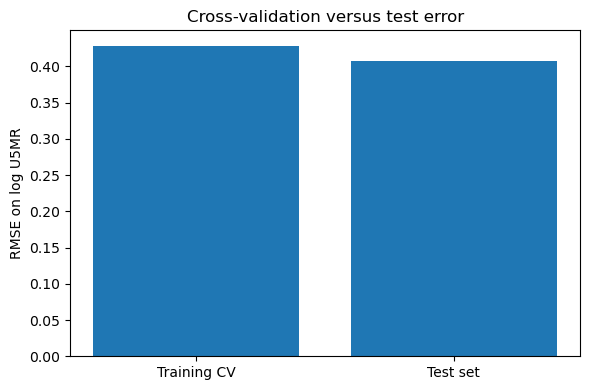

,evaluation,rmse_log
0,Training CV,0.428217
1,Test set,0.407635


In [394]:
best_cv_rmse = combined_cv_selection.loc[
    combined_cv_selection["model"] == final_model_name,
    "cv_rmse_log_mean"
].iloc[0]

cv_test_comparison = pd.DataFrame({
    "evaluation": ["Training CV", "Test set"],
    "rmse_log": [best_cv_rmse, final_metrics["rmse_log"]]
})

cv_test_comparison.to_csv(TABLE_DIR / "cv_test_rmse_comparison.csv", index=False)

plt.figure(figsize=(6, 4))
plt.bar(cv_test_comparison["evaluation"], cv_test_comparison["rmse_log"])
plt.title("Cross-validation versus test error")
plt.ylabel("RMSE on log U5MR")
plt.tight_layout()
plt.savefig(VIS_DIR / "cv_vs_test_rmse.png", dpi=300)
plt.show()

display(cv_test_comparison)

## 10.7 Bootstrap uncertainty for final test metrics


In [396]:
bootstrap_rows = []
rng = np.random.default_rng(RANDOM_STATE)
y_test_array = np.asarray(y_test)
pred_array = np.asarray(final_test_pred_log)

for _ in range(500):
    sample_idx = rng.integers(0, len(y_test_array), size=len(y_test_array))
    y_boot = y_test_array[sample_idx]
    pred_boot = pred_array[sample_idx]
    bootstrap_rows.append(evaluate_predictions(y_boot, pred_boot))

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_ci = bootstrap_df.quantile([0.025, 0.5, 0.975]).T.rename(columns={0.025: "ci_2_5", 0.5: "median", 0.975: "ci_97_5"})
bootstrap_ci.to_csv(TABLE_DIR / "final_test_metric_bootstrap_ci.csv")
display(bootstrap_ci)

,ci_2_5,median,ci_97_5
rmse_log,0.301921,0.407610,0.491308
mae_log,0.218087,0.306455,0.389660
r2_log,0.758734,0.842446,0.907245
mae_original_scale,4.511899,8.233818,13.196694


## 10.8 Save final predictions


In [398]:
final_predictions = test_model_data[["country_code", "country_name", "u5mr_2023", "log_u5mr_2023"]].copy()
final_predictions["pred_log_u5mr_2023"] = final_test_pred_log
final_predictions["pred_u5mr_2023"] = np.exp(final_test_pred_log)
final_predictions["residual_log"] = final_predictions["log_u5mr_2023"] - final_predictions["pred_log_u5mr_2023"]
final_predictions["absolute_error_original"] = (final_predictions["u5mr_2023"] - final_predictions["pred_u5mr_2023"]).abs()

final_predictions.to_csv(DATA_DIR / "final_test_predictions.csv", index=False)
display(final_predictions.sort_values("absolute_error_original", ascending=False).head(10))

,country_code,country_name,u5mr_2023,log_u5mr_2023,pred_log_u5mr_2023,pred_u5mr_2023,residual_log,absolute_error_original
1,NER,Niger,114.8,4.743191,3.887622,48.794731,0.855569,66.005269
124,SOM,"Somalia, Federal Republic of",104.0,4.644391,3.801675,44.776125,0.842716,59.223875
100,PAK,Pakistan,58.5,4.069027,3.309903,27.382471,0.759124,31.117529
28,GNB,Guinea-Bissau,69.3,4.238445,3.914590,50.128538,0.323854,19.171462
54,LSO,Lesotho,58.9,4.075841,3.768025,43.294482,0.307816,15.605518
18,MDG,Madagascar,64.8,4.171306,3.915898,50.194108,0.255408,14.605892
20,BDI,Burundi,49.2,3.895894,4.153798,63.675398,-0.257905,14.475398
129,PLW,Palau,22.3,3.104587,2.340431,10.385710,0.764156,11.914290
36,TTO,Trinidad and Tobago,19.1,2.949688,2.107962,8.231448,0.841726,10.868552
51,HND,Honduras,15.5,2.740840,3.232981,25.355133,-0.492141,9.855133


## 10.9 Subgroup error analysis

Overall RMSE and MAE can hide uneven performance across groups of countries. This diagnostic section evaluates errors by U5MR level and, when available, by an income proxy from WDI. The subgroup analysis is not used for model selection; it is used only to understand where the final model performs better or worse.

The groups are built only after final model evaluation, so they do not affect training, feature selection, or tuning.


No sufficiently complete WDI income proxy was available for test-country subgroup analysis.


,grouping_variable,group,n_countries,mean_actual_u5mr,median_actual_u5mr,mae_original_scale,rmse_log,mean_residual_log_actual_minus_predicted
0,u5mr_test_quartile,highest U5MR countries,9,68.366667,58.90,25.484769,0.513954,0.367011
1,u5mr_test_quartile,lower-middle U5MR countries,9,12.200000,12.00,2.825954,0.239176,-0.039010
2,u5mr_test_quartile,lowest U5MR countries,10,4.420000,4.25,1.632178,0.416463,-0.193841
3,u5mr_test_quartile,upper-middle U5MR countries,9,26.466667,23.10,4.605242,0.411169,0.269452


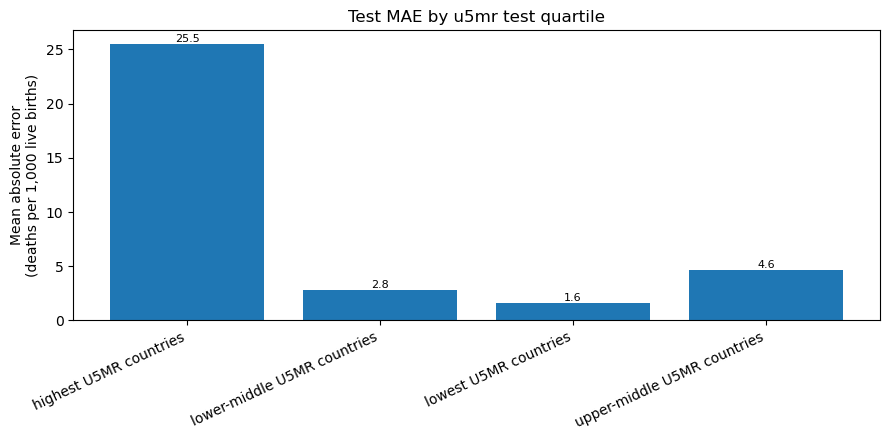

In [400]:
def make_quantile_groups(series, labels):
    """Create quantile groups with robust handling of tied values."""
    series = pd.Series(series)
    try:
        codes = pd.qcut(series, q=len(labels), labels=False, duplicates="drop")
        if codes.notna().sum() == 0:
            return pd.Series(pd.NA, index=series.index, dtype="object")
        n_groups = int(codes.max()) + 1
        label_map = {i: labels[i] for i in range(n_groups)}
        return codes.map(label_map).astype("object")
    except ValueError:
        return pd.Series(pd.NA, index=series.index, dtype="object")

u5mr_group_labels = [
    "lowest U5MR countries",
    "lower-middle U5MR countries",
    "upper-middle U5MR countries",
    "highest U5MR countries"
]
final_predictions["u5mr_test_quartile"] = make_quantile_groups(
    final_predictions["u5mr_2023"],
    u5mr_group_labels
)

income_proxy_candidates = [
    ("NY.GNP.PCAP.CD", "GNI per capita, Atlas method, current US$"),
    ("NY.GDP.PCAP.CD", "GDP per capita, current US$"),
    ("NY.GDP.PCAP.KD", "GDP per capita, constant 2015 US$"),
]

best_income_proxy = None
best_income_proxy_label = None
best_income_proxy_coverage = -1

for indicator_code, indicator_label in income_proxy_candidates:
    candidate_rows = country_wdi[country_wdi["indicator_code"] == indicator_code].copy()
    if candidate_rows.empty:
        continue

    candidate_values = (
        fixed_year_values(
            candidate_rows,
            PREDICTOR_LEVEL_YEAR,
            value_name="income_proxy_2022"
        )[["country_code", "income_proxy_2022"]]
        .drop_duplicates(subset=["country_code"])
    )

    coverage = (
        final_predictions[["country_code"]]
        .merge(candidate_values, on="country_code", how="left")["income_proxy_2022"]
        .notna()
        .mean()
    )

    if coverage > best_income_proxy_coverage:
        best_income_proxy = candidate_values
        best_income_proxy_label = indicator_label
        best_income_proxy_coverage = coverage

if best_income_proxy is not None and best_income_proxy_coverage >= 0.50:
    final_predictions = final_predictions.merge(best_income_proxy, on="country_code", how="left")
    income_group_labels = [
        "lowest income-proxy countries",
        "lower-middle income-proxy countries",
        "upper-middle income-proxy countries",
        "highest income-proxy countries"
    ]
    final_predictions["income_proxy_quartile"] = make_quantile_groups(
        final_predictions["income_proxy_2022"],
        income_group_labels
    )
    print(f"Income proxy used for subgroup analysis: {best_income_proxy_label}")
    print(f"Income proxy coverage in test set: {best_income_proxy_coverage:.1%}")
else:
    final_predictions["income_proxy_2022"] = np.nan
    final_predictions["income_proxy_quartile"] = pd.NA
    print("No sufficiently complete WDI income proxy was available for test-country subgroup analysis.")


def subgroup_metric_table(prediction_df, group_column):
    rows = []
    valid_df = prediction_df.dropna(subset=[group_column]).copy()

    for group_value, group_df in valid_df.groupby(group_column, observed=True):
        if len(group_df) == 0:
            continue

        rmse_log_group = np.sqrt(
            np.mean((group_df["log_u5mr_2023"] - group_df["pred_log_u5mr_2023"]) ** 2)
        )

        rows.append({
            "grouping_variable": group_column,
            "group": str(group_value),
            "n_countries": len(group_df),
            "mean_actual_u5mr": group_df["u5mr_2023"].mean(),
            "median_actual_u5mr": group_df["u5mr_2023"].median(),
            "mae_original_scale": group_df["absolute_error_original"].mean(),
            "rmse_log": rmse_log_group,
            "mean_residual_log_actual_minus_predicted": group_df["residual_log"].mean()
        })

    return pd.DataFrame(rows)

subgroup_tables = [subgroup_metric_table(final_predictions, "u5mr_test_quartile")]

if final_predictions["income_proxy_quartile"].notna().sum() >= 8:
    subgroup_tables.append(subgroup_metric_table(final_predictions, "income_proxy_quartile"))

subgroup_error_table = pd.concat(subgroup_tables, ignore_index=True)
subgroup_error_table.to_csv(TABLE_DIR / "subgroup_error_analysis_test_set.csv", index=False)
final_predictions.to_csv(DATA_DIR / "final_test_predictions_with_subgroups.csv", index=False)

display(subgroup_error_table)

for group_var in subgroup_error_table["grouping_variable"].unique():
    plot_df = subgroup_error_table[subgroup_error_table["grouping_variable"] == group_var].copy()

    plt.figure(figsize=(9, 4.5))
    plt.bar(plot_df["group"], plot_df["mae_original_scale"])
    plt.title(f"Test MAE by {group_var.replace('_', ' ')}")
    plt.ylabel("Mean absolute error\n(deaths per 1,000 live births)")
    plt.xlabel("")
    plt.xticks(rotation=25, ha="right")

    for i, value in enumerate(plot_df["mae_original_scale"]):
        plt.text(i, value, f"{value:.1f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    safe_group_name = group_var.replace(" ", "_").lower()
    plt.savefig(VIS_DIR / f"test_mae_by_{safe_group_name}.png", dpi=300)
    plt.show()

### Subgroup-error interpretation

The subgroup table should be read as a diagnostic check, not as a separate model-selection procedure. Some groups contain few countries, so differences in subgroup MAE or RMSE can be unstable. Nevertheless, the table is useful because it shows whether the model errors are concentrated among low-mortality, high-mortality, lower-income, or higher-income countries.

## 10.10 Actual vs predicted plot


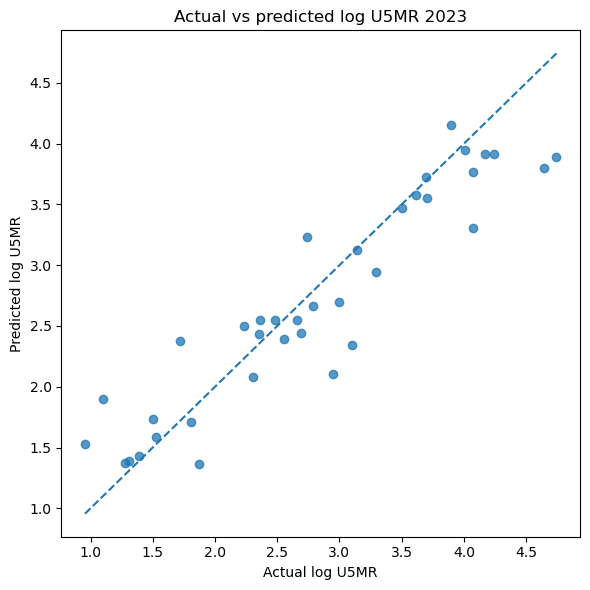

In [403]:
plt.figure(figsize=(6, 6))
plt.scatter(final_predictions["log_u5mr_2023"], final_predictions["pred_log_u5mr_2023"], alpha=0.75)
min_value = min(final_predictions["log_u5mr_2023"].min(), final_predictions["pred_log_u5mr_2023"].min())
max_value = max(final_predictions["log_u5mr_2023"].max(), final_predictions["pred_log_u5mr_2023"].max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.title("Actual vs predicted log U5MR 2023")
plt.xlabel("Actual log U5MR")
plt.ylabel("Predicted log U5MR")
plt.tight_layout()
plt.savefig(VIS_DIR / "actual_vs_predicted_log_u5mr.png", dpi=300)
plt.show()

## 10.11 Residual plot


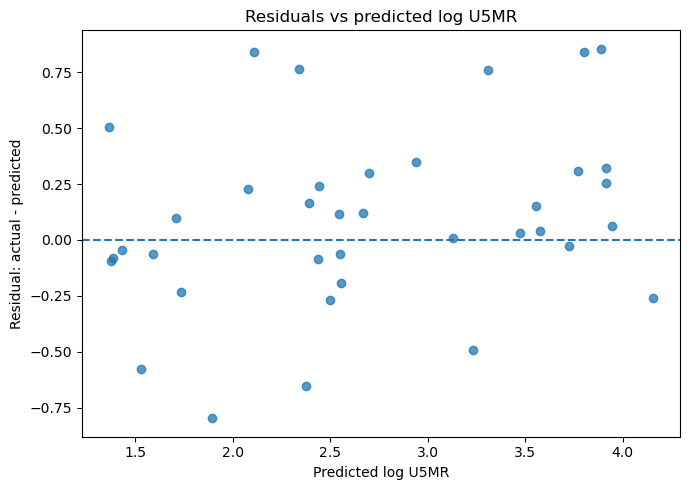

In [405]:
plt.figure(figsize=(7, 5))
plt.scatter(final_predictions["pred_log_u5mr_2023"], final_predictions["residual_log"], alpha=0.75)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs predicted log U5MR")
plt.xlabel("Predicted log U5MR")
plt.ylabel("Residual: actual - predicted")
plt.tight_layout()
plt.savefig(VIS_DIR / "residuals_vs_predicted_log_u5mr.png", dpi=300)
plt.show()

## 10.12 Permutation feature importance


In [407]:
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_table = pd.DataFrame({
    "feature": kept_feature_columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_table = importance_table.merge(
    feature_dictionary[["feature", "predictor_name", "feature_type", "domain", "indicator_name"]],
    on="feature",
    how="left"
)

importance_table.to_csv(TABLE_DIR / "permutation_feature_importance.csv", index=False)
display(importance_table.head(15))

,feature,importance_mean,importance_std,predictor_name,feature_type,domain,indicator_name
0,health_exp_change_2018_2022,0.040073,0.016526,health_exp,change from 2018 to 2022,health system,Domestic general government health expenditure...
1,health_exp_2022,0.038503,0.017624,health_exp,value in 2022,health system,Domestic general government health expenditure...
2,self_employed_employment_mean_2018_2022,0.029035,0.010354,self_employed_employment,mean from 2018 to 2022,economic,"Self-employed, total (% of total employment) (..."
3,fixed_broadband_subscriptions_mean_2018_2022,0.028255,0.017014,fixed_broadband_subscriptions,mean from 2018 to 2022,infrastructure,Fixed broadband subscriptions (per 100 people)
4,elderly_share_mean_2018_2022,0.025790,0.009475,elderly_share,mean from 2018 to 2022,demographic,"Population ages 80 and above, male (% of male ..."
5,electricity_access_2_2022,0.025647,0.011431,electricity_access_2,value in 2022,infrastructure,Access to electricity (% of population)
6,food_insecurity_mean_2018_2022,0.023923,0.011326,food_insecurity,mean from 2018 to 2022,demographic,Prevalence of moderate or severe food insecuri...
7,ages_2022,0.021632,0.010244,ages,value in 2022,demographic,"Population ages 55-59, female (% of female pop..."
8,uhc_service_coverage_2_mean_2018_2022,0.020479,0.012469,uhc_service_coverage_2,mean from 2018 to 2022,health system,UHC service coverage sub-index on service capa...
9,adolescent_fertility_2022,0.018286,0.009879,adolescent_fertility,value in 2022,demographic,"Adolescent fertility rate (births per 1,000 wo..."


## 10.13 Feature importance plot


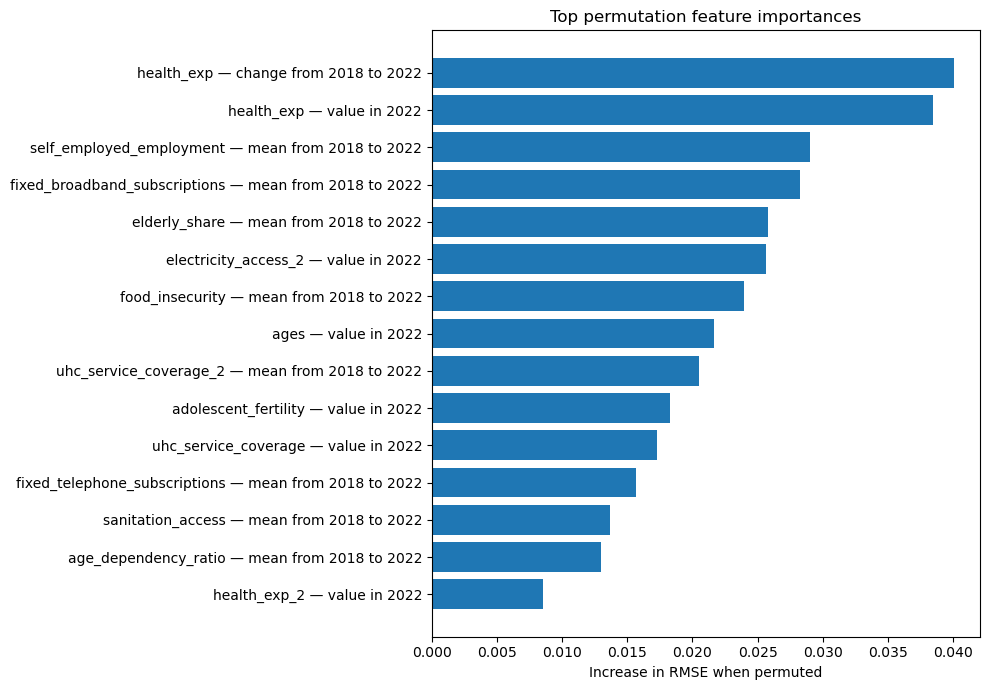

In [409]:
plot_importance = importance_table.head(15).copy().sort_values("importance_mean")
plot_labels = plot_importance["predictor_name"] + " — " + plot_importance["feature_type"]

plt.figure(figsize=(10, 7))
plt.barh(plot_labels, plot_importance["importance_mean"])
plt.title("Top permutation feature importances")
plt.xlabel("Increase in RMSE when permuted")
plt.tight_layout()
plt.savefig(VIS_DIR / "permutation_feature_importance.png", dpi=300)
plt.show()

## 10.14 Top-feature robustness check

Feature importance is useful for interpretation, but it should not automatically replace the full model. To test whether the most important predictors are enough, we build simplified models with only the top-ranked predictors and compare them with the full model.

The top predictors are selected using training data only. The test set is used only for the final comparison.


In [411]:
train_perm = permutation_importance(
    final_model,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

train_importance_table = pd.DataFrame({
    "feature": kept_feature_columns,
    "importance_mean": train_perm.importances_mean,
    "importance_std": train_perm.importances_std
}).sort_values("importance_mean", ascending=False)

train_importance_table = train_importance_table.merge(
    feature_dictionary[["feature", "predictor_name", "feature_type", "domain", "indicator_name"]],
    on="feature",
    how="left"
)

train_importance_table.to_csv(TABLE_DIR / "train_only_feature_importance_for_top_feature_check.csv", index=False)

top_feature_counts = [5, 10, 15]
top_feature_results = []
top_feature_models = {}

for top_k in top_feature_counts:
    available_k = min(top_k, len(train_importance_table))
    top_features = train_importance_table.head(available_k)["feature"].tolist()

    X_train_top = X_train[top_features].copy()
    X_test_top = X_test[top_features].copy()

    top_model = clone(final_model)
    top_model.fit(X_train_top, y_train)

    top_pred_log = top_model.predict(X_test_top)
    top_metrics = evaluate_predictions(y_test, top_pred_log)

    top_feature_results.append({
        "model": f"{final_model_name} with top {available_k} training-ranked features",
        "model_type": "top_feature_model",
        "number_of_features": available_k,
        **top_metrics
    })

    top_feature_models[f"top_{available_k}"] = top_model

top_feature_results = pd.DataFrame(top_feature_results)

full_model_row = pd.DataFrame([{
    "model": f"{final_model_name} full model",
    "model_type": "full_model",
    "number_of_features": len(kept_feature_columns),
    **final_metrics
}])

top_feature_comparison = pd.concat(
    [full_model_row, top_feature_results],
    ignore_index=True
)

top_feature_comparison.to_csv(TABLE_DIR / "full_vs_top_feature_model_comparison.csv", index=False)

best_top_feature_row = top_feature_results.sort_values("rmse_log").iloc[0]

if best_top_feature_row["rmse_log"] <= final_metrics["rmse_log"]:
    top_feature_summary_sentence = (
        f"The best simplified model used the top {int(best_top_feature_row['number_of_features'])} training-ranked features "
        f"and achieved RMSE_log = {best_top_feature_row['rmse_log']:.3f}, compared with "
        f"{final_metrics['rmse_log']:.3f} for the full model. This suggests that most predictive information is concentrated in a smaller group of predictors."
    )
elif best_top_feature_row["rmse_log"] <= final_metrics["rmse_log"] * 1.05:
    top_feature_summary_sentence = (
        f"The best simplified model used the top {int(best_top_feature_row['number_of_features'])} training-ranked features "
        f"and achieved RMSE_log = {best_top_feature_row['rmse_log']:.3f}, which is close to "
        f"{final_metrics['rmse_log']:.3f} for the full model. This suggests that the model is not fully dependent on all predictors."
    )
else:
    top_feature_summary_sentence = (
        f"The best simplified model used the top {int(best_top_feature_row['number_of_features'])} training-ranked features "
        f"and achieved RMSE_log = {best_top_feature_row['rmse_log']:.3f}, compared with "
        f"{final_metrics['rmse_log']:.3f} for the full model. This suggests that the lower-ranked predictors still add useful information."
    )

print(top_feature_summary_sentence)
display(top_feature_comparison)

The best simplified model used the top 10 training-ranked features and achieved RMSE_log = 0.406, compared with 0.408 for the full model. This suggests that most predictive information is concentrated in a smaller group of predictors.


,model,model_type,number_of_features,rmse_log,mae_log,r2_log,mae_original_scale
0,Extra Trees tuned full model,full_model,25,0.407635,0.305385,0.848627,8.447715
1,Extra Trees tuned with top 5 training-ranked f...,top_feature_model,5,0.473922,0.369762,0.795393,9.820057
2,Extra Trees tuned with top 10 training-ranked ...,top_feature_model,10,0.406259,0.328026,0.849647,9.102835
3,Extra Trees tuned with top 15 training-ranked ...,top_feature_model,15,0.407378,0.312173,0.848818,8.757918


## 10.15 Full model versus top-feature models

This plot compares the full model with smaller models that use only the most important training-ranked predictors. If a smaller model performs close to the full model, it means the strongest predictors carry most of the signal. If the full model performs better, it means the remaining predictors still add useful information.


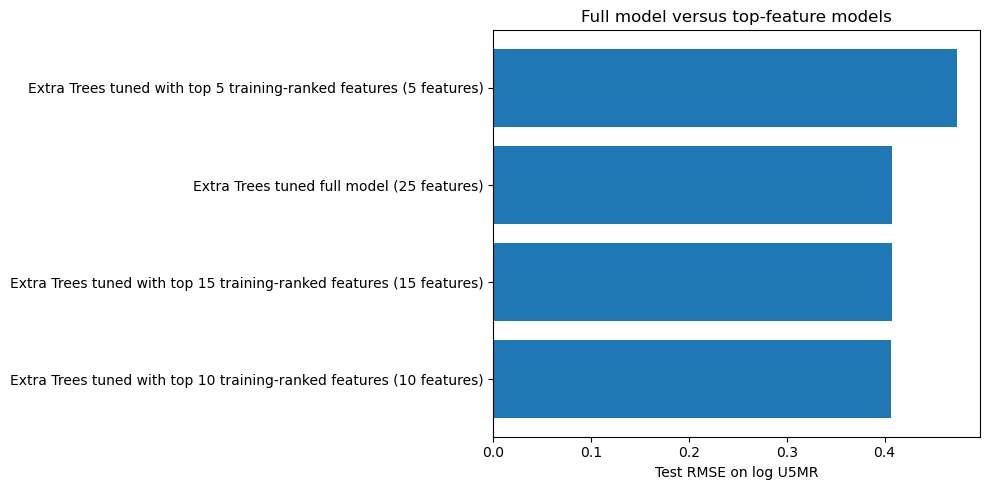

In [413]:
plot_top_feature_comparison = top_feature_comparison.copy()
plot_top_feature_comparison["plot_label"] = plot_top_feature_comparison["model"] + " (" + plot_top_feature_comparison["number_of_features"].astype(str) + " features)"
plot_top_feature_comparison = plot_top_feature_comparison.sort_values("rmse_log", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_top_feature_comparison["plot_label"], plot_top_feature_comparison["rmse_log"])
plt.xlabel("Test RMSE on log U5MR")
plt.title("Full model versus top-feature models")
plt.tight_layout()
plt.savefig(VIS_DIR / "full_vs_top_feature_models.png", dpi=300)
plt.show()

## 10.16 Report-ready interpretation paragraph


In [415]:
top_importance_rows = importance_table.head(5).copy()

def format_predictor_for_text(row):
    predictor = str(row["predictor_name"]).replace("_", " ")
    feature_type = str(row["feature_type"])
    domain = str(row["domain"])
    return f"{predictor} ({feature_type}; {domain})"

top_predictor_text = "; ".join(
    top_importance_rows.apply(format_predictor_for_text, axis=1).tolist()
)

proxy_predictors = [
    str(name).replace("_", " ")
    for name in top_importance_rows["predictor_name"].dropna().unique()
    if any(term in str(name).lower() for term in ["broadband", "server", "internet", "electricity"])
]

if proxy_predictors:
    proxy_sentence = (
        " Infrastructure and digital-access predictors such as "
        + ", ".join(proxy_predictors)
        + " are interpreted as broad development proxies rather than direct causal mechanisms."
    )
else:
    proxy_sentence = ""

if "subgroup_error_table" in globals() and len(subgroup_error_table) > 0:
    largest_error_row = subgroup_error_table.sort_values("mae_original_scale", ascending=False).iloc[0]
    subgroup_sentence = (
        f" The subgroup diagnostic found the largest mean absolute error in the "
        f"'{largest_error_row['group']}' group under {largest_error_row['grouping_variable']}, "
        f"but subgroup results should be interpreted cautiously because each group contains few countries."
    )
else:
    subgroup_sentence = ""

sample_size_sentence = (
    f" Because the evaluation uses {len(y_test)} test countries and the training set is small, "
    "the reported metrics should be interpreted together with the bootstrap confidence intervals."
)

if "top_feature_summary_sentence" in globals():
    top_feature_sentence = " " + top_feature_summary_sentence
else:
    top_feature_sentence = ""

report_paragraph = (
    f"The selected {final_model_name} model achieved test RMSE_log = {final_metrics['rmse_log']:.3f} "
    f"compared with the dummy baseline RMSE_log = {dummy_metrics['rmse_log']:.3f}, representing a "
    f"{improvement_over_dummy:.1f}% improvement. The test R² of {final_metrics['r2_log']:.3f} means "
    f"the model explains approximately {final_metrics['r2_log'] * 100:.1f}% of the cross-country variation "
    f"in log under-five mortality. The most important predictors were {top_predictor_text}. These variables "
    f"suggest that economic conditions, demographic structure, health and nutrition, education/social conditions, "
    f"and infrastructure are useful for predicting cross-country differences in child mortality."
    f"{proxy_sentence}{top_feature_sentence} {sample_size_sentence}{subgroup_sentence} "
    "The results should be interpreted as predictive associations, not causal effects."
)

print(report_paragraph)
with open(REPORT_DIR / "final_report_ready_paragraph.txt", "w", encoding="utf-8") as f:
    f.write(report_paragraph)

The selected Extra Trees tuned model achieved test RMSE_log = 0.408 compared with the dummy baseline RMSE_log = 1.054, representing a 61.3% improvement. The test R² of 0.849 means the model explains approximately 84.9% of the cross-country variation in log under-five mortality. The most important predictors were health exp (change from 2018 to 2022; health system); health exp (value in 2022; health system); self employed employment (mean from 2018 to 2022; economic); fixed broadband subscriptions (mean from 2018 to 2022; infrastructure); elderly share (mean from 2018 to 2022; demographic). These variables suggest that economic conditions, demographic structure, health and nutrition, education/social conditions, and infrastructure are useful for predicting cross-country differences in child mortality. Infrastructure and digital-access predictors such as fixed broadband subscriptions are interpreted as broad development proxies rather than direct causal mechanisms. The best simplified mo

## 10.17 Hypothesis check

The hypotheses are answered after the final evaluation because they depend on the selected model, the test metrics, and the final feature-importance results.


In [417]:
top_domains = importance_table.head(10)["domain"].dropna().unique().tolist()
aggregation_features_selected = [
    feature for feature in kept_feature_columns
    if f"_mean_{MEAN_START_YEAR}_{MEAN_END_YEAR}" in feature
    or f"_change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}" in feature
]
top_aggregation_features = [
    feature for feature in importance_table.head(10)["feature"]
    if f"_mean_{MEAN_START_YEAR}_{MEAN_END_YEAR}" in feature
    or f"_change_{CHANGE_START_YEAR}_{CHANGE_END_YEAR}" in feature
]

ensemble_keywords = ["Extra Trees", "Random Forest", "Gradient Boosting", "XGBoost"]


if "top_feature_comparison" in globals():
    best_top_feature_row_for_hypothesis = top_feature_comparison[top_feature_comparison["model_type"] == "top_feature_model"].sort_values("rmse_log").iloc[0]
    top_feature_decision = "supported" if best_top_feature_row_for_hypothesis["rmse_log"] <= final_metrics["rmse_log"] * 1.05 else "not strongly supported"
    top_feature_evidence = (
        f"Best top-feature model used {int(best_top_feature_row_for_hypothesis['number_of_features'])} features and reached "
        f"RMSE_log = {best_top_feature_row_for_hypothesis['rmse_log']:.3f}, compared with {final_metrics['rmse_log']:.3f} for the full model."
    )
else:
    top_feature_decision = "not evaluated"
    top_feature_evidence = "Top-feature robustness check was not available."

hypothesis_results = pd.DataFrame([
    {
        "hypothesis": "H1",
        "statement": "Lagged WDI indicators predict U5MR 2023 better than the dummy baseline.",
        "decision": "supported" if improvement_over_dummy > 0 else "not supported",
        "evidence": f"RMSE_log improved by {improvement_over_dummy:.1f}% compared with Dummy mean."
    },
    {
        "hypothesis": "H2",
        "statement": "The selected WDI indicators explain a large share of cross-country variation in log U5MR 2023.",
        "decision": "supported" if final_metrics["r2_log"] >= 0.50 else "partly supported",
        "evidence": f"Test R² = {final_metrics['r2_log']:.3f}."
    },
    {
        "hypothesis": "H3",
        "statement": "Useful predictors come from several development domains.",
        "decision": "supported" if len(top_domains) >= 3 else "partly supported",
        "evidence": "Top-10 importance domains: " + ", ".join(top_domains)
    },
    {
        "hypothesis": "H4",
        "statement": "Aggregated historical features add useful pre-target information.",
        "decision": "supported" if len(top_aggregation_features) > 0 else "not strongly supported",
        "evidence": f"{len(aggregation_features_selected)} selected predictors were mean/change features; {len(top_aggregation_features)} appeared in the top 10 importances."
    },
    {
        "hypothesis": "H5",
        "statement": "A non-linear ensemble model performs best for this task.",
        "decision": "supported" if any(keyword in final_model_name for keyword in ensemble_keywords) else "not supported",
        "evidence": f"Final model selected by training CV: {final_model_name}."
    },
    {
        "hypothesis": "H6",
        "statement": "A smaller top-feature model can reach similar performance to the full model.",
        "decision": top_feature_decision,
        "evidence": top_feature_evidence
    }
])

hypothesis_results.to_csv(TABLE_DIR / "hypothesis_results.csv", index=False)
display(hypothesis_results)

hypothesis_text = "\n".join(
    f"{row['hypothesis']}: {row['decision']} — {row['evidence']}"
    for _, row in hypothesis_results.iterrows()
)

with open(REPORT_DIR / "hypothesis_results_summary.txt", "w", encoding="utf-8") as f:
    f.write(hypothesis_text)

print(hypothesis_text)

,hypothesis,statement,decision,evidence
0,H1,Lagged WDI indicators predict U5MR 2023 better...,supported,RMSE_log improved by 61.3% compared with Dummy...
1,H2,The selected WDI indicators explain a large sh...,supported,Test R² = 0.849.
2,H3,Useful predictors come from several developmen...,supported,"Top-10 importance domains: health system, econ..."
3,H4,Aggregated historical features add useful pre-...,supported,18 selected predictors were mean/change featur...
4,H5,A non-linear ensemble model performs best for ...,supported,Final model selected by training CV: Extra Tre...
5,H6,A smaller top-feature model can reach similar ...,supported,Best top-feature model used 10 features and re...


H1: supported — RMSE_log improved by 61.3% compared with Dummy mean.
H2: supported — Test R² = 0.849.
H3: supported — Top-10 importance domains: health system, economic, infrastructure, demographic
H4: supported — 18 selected predictors were mean/change features; 6 appeared in the top 10 importances.
H5: supported — Final model selected by training CV: Extra Trees tuned.
H6: supported — Best top-feature model used 10 features and reached RMSE_log = 0.406, compared with 0.408 for the full model.
